In [6]:
import pandas as pd

# Per-architecture function node token length statistics
stats = {
    "Architecture": ["ARM-32", "ARM-64", "Intel", "MIPS", "PPC", "x86_64", "Overall"],
    "Files":        [6230, 846, 6708, 5995, 6986, 6547, 33312],
    "Nodes":        [3742645, 858786, 6245389, 2504173, 1532672, 5966175, 20849840],
    "Mean":         [250.3, 195.7, 166.7, 201.5, 152.7, 143.9, 179.5],
    "p50":          [33, 40, 26, 38, 22, 27, 28],
    "p75":          [115, 133, 85, 111, 76, 82, 93],
    "p90":          [396, 392, 286, 325, 171, 244, 296],
    "p95":          [878, 712, 595, 723, 486, 503, 625],
    "<=128 (%)": [77.0, 74.4, 81.5, 77.4, 87.7, 82.7, 80.7],
    "<=256 (%)": [85.8, 85.3, 89.0, 86.9, 91.8, 90.4, 88.6],
    "<=512 (%)": [92.1, 92.4, 94.0, 93.2, 95.0, 95.1, 93.9],
}

df_stats = pd.DataFrame(stats).set_index("Architecture")
df_stats


,Files,Nodes,Mean,p50,p75,p90,p95,<=128 (%),<=256 (%),<=512 (%)
Architecture,,,,,,,,,,
ARM-32,6230,3742645,250.3,33,115,396,878,77.0,85.8,92.1
ARM-64,846,858786,195.7,40,133,392,712,74.4,85.3,92.4
Intel,6708,6245389,166.7,26,85,286,595,81.5,89.0,94.0
MIPS,5995,2504173,201.5,38,111,325,723,77.4,86.9,93.2
PPC,6986,1532672,152.7,22,76,171,486,87.7,91.8,95.0
x86_64,6547,5966175,143.9,27,82,244,503,82.7,90.4,95.1
Overall,33312,20849840,179.5,28,93,296,625,80.7,88.6,93.9


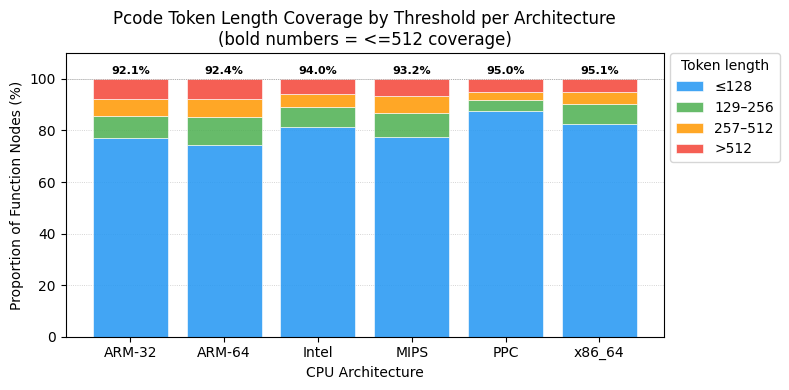

Saved -> /home/tommy/Project/PCBSDA/ours/notebooks/raw_data/token_length_coverage_bar.png


In [7]:
import matplotlib.pyplot as plt
import numpy as np

df_arch = df_stats.drop(index='Overall')

ARCH_LABEL = df_arch.index.tolist()
n = len(ARCH_LABEL)

le128 = df_arch['<=128 (%)'].values
le256 = df_arch['<=256 (%)'].values
le512 = df_arch['<=512 (%)'].values

bars_data = np.column_stack([
    le128,
    le256 - le128,
    le512 - le256,
    100   - le512,
])

bins_labels = [u'\u2264128', u'129\u2013256', u'257\u2013512', u'>512']
bin_colors  = ['#2196F3', '#4CAF50', '#FF9800', '#F44336']

fig2, ax2 = plt.subplots(figsize=(8, 4))
bottoms = np.zeros(n)

for j, (label, color) in enumerate(zip(bins_labels, bin_colors)):
    ax2.bar(ARCH_LABEL, bars_data[:, j], bottom=bottoms,
            label=label, color=color, alpha=0.85, edgecolor='white', linewidth=0.5)
    bottoms += bars_data[:, j]

# Annotate with <=512 coverage
for i in range(n):
    ax2.text(i, 101, f'{le512[i]:.1f}%', ha='center', va='bottom',
             fontsize=8, fontweight='bold', color='black')

ax2.axhline(100, color='gray', linewidth=0.5, linestyle=':')
ax2.set_ylim(0, 110)
ax2.set_ylabel('Proportion of Function Nodes (%)')
ax2.set_xlabel('CPU Architecture')
ax2.set_title('Pcode Token Length Coverage by Threshold per Architecture\n'
              '(bold numbers = <=512 coverage)')
ax2.legend(title='Token length', loc='upper left',
           bbox_to_anchor=(1.01, 1), borderaxespad=0)
ax2.yaxis.grid(True, linestyle=':', linewidth=0.6, alpha=0.7)
ax2.set_axisbelow(True)

plt.tight_layout()
out_path2 = '/home/tommy/Project/PCBSDA/ours/notebooks/raw_data/token_length_coverage_bar.png'
plt.savefig(out_path2, dpi=600, bbox_inches='tight')
plt.show()
print(f'Saved -> {out_path2}')
